# Taller de Optimización: Funciones de Orden Superior y Decoradores
**Bootcamp Python PY4 — Módulo 1: Python y Manipulación de Datos**

---

En este taller vas a trabajar con un pipeline de procesamiento de datos ineficiente.
Tu misión es diagnosticarlo, medir sus problemas y refactorizarlo usando las herramientas
de la pila científica de Python.

El flujo de trabajo es el siguiente:

1. **Fase 1 — Profiling y Diagnóstico:** medir tiempos de CPU y consumo de RAM antes de tocar cualquier línea.
2. **Fase 2 — Decoradores personalizados:** construir un decorador `@monitor_rendimiento` que envuelva funciones de procesamiento.
3. **Fase 3 — Refactorización:** reemplazar bucles con NumPy (broadcasting + fancy indexing), optimizar con SciPy y modelar con Statsmodels.
4. **Ejercicio final:** aplicar lo aprendido de forma autónoma con un dataset diferente.

**Herramientas:** `cProfile`, `memory_profiler`, `time`, `numpy`, `scipy`, `statsmodels`


---
## Instalación de dependencias

Antes de arrancar, asegurate de tener las librerías necesarias. Ejecuta la celda siguiente una sola vez.


In [ ]:
%pip install memory_profiler numpy scipy statsmodels --quiet

---
## Fase 1: Profiling y Diagnóstico

### El problema

Recibiste el siguiente pipeline de procesamiento. Funciona, pero un colega se queja de que
tarda demasiado con datasets grandes. **No toques el código todavía** — primero hay que medir.

Lee el código con atención y trata de identificar a ojo dónde pueden estar los problemas.


In [1]:
import numpy as np
import time

# ── Código base ineficiente ──────────────────────────────────────────────────
# Este script simula un pipeline de procesamiento de ventas con 1 millón de registros.
# Está escrito deliberadamente con patrones lentos para que podamos medirlos y mejorarlos.

def generar_datos(n=1_000_000):
    """Genera un dataset simulado de transacciones de ventas."""

    np.random.seed(42)  # Fija la semilla para obtener los mismos resultados cuando se vuelve a ejecutar el código

    datos = {
        "ventas": list(np.random.uniform(10, 500, n)),  # Datos de ventas aleatorias entre 10 y 500
        "descuentos": list(np.random.uniform(0, 0.3, n)),  # Descuentos entre 0% y 30%
        "categoria": list(np.random.randint(1, 6, n)),  # Categorias entre 1 y 5
    }

    return datos  # Devuelve los datos en forma de diccionario


def calcular_ventas_netas(datos):
    """Calcula venta neta = venta * (1 - descuento) usando un bucle for."""

    resultado = []  # Lista donde se guardaran las ventas netas

    for i in range(len(datos["ventas"])):  # Recorre cada registro
        neto = datos["ventas"][i] * (1 - datos["descuentos"][i])  # Aplica descuento
        resultado.append(neto)  # Guarda el resultado

    return resultado  # Devuelve la lista de ventas netas


def filtrar_premium(ventas_netas):
    """Filtra ventas mayores a 300 usando if/else dentro de un bucle."""

    premium = []  # Lista para ventas premium

    for v in ventas_netas:  # Recorre cada venta neta
        if v > 300:  # Conserva solo las mayores a 300
            premium.append(v)

    return premium  # Devuelve las ventas premium


def calcular_estadisticas(valores):
    """Calcula media y desviación estándar de forma manual con un bucle."""

    n = len(valores)  # Cantidad de elementos

    media = sum(valores) / n  # Calcula la media

    varianza = sum(
        (x - media) ** 2 for x in valores
    ) / n  # Calcula la varianza

    return media, varianza ** 0.5  # Devuelve media y desviacion estandar


# ── Prueba rápida ────────────────────────────────────────────────────────────

datos = generar_datos()  # Genera un millon de registros

ventas_netas = calcular_ventas_netas(datos)  # Calcula ventas despues del descuento

premium = filtrar_premium(ventas_netas)  # Filtra ventas premium

media, std = calcular_estadisticas(premium)  # Calcula estadisticas

print(f"Registros totales:    {len(ventas_netas):,}")  # Total de ventas
print(f"Ventas premium:       {len(premium):,}")  # Total de ventas premium
print(f"Media ventas premium: {media:.2f}")  # Promedio de ventas premium
print(f"Desv. estándar:       {std:.2f}")  # Dispersion de las ventas premium


Registros totales:    1,000,000
Ventas premium:       292,896
Media ventas premium: 368.08
Desv. estándar:       46.01


---
### Paso 1: Medir tiempos de CPU con `cProfile`

`cProfile` es el profiler estándar de Python. Cuenta cuántas veces se llama cada función
y cuánto tiempo acumula en total.

**Cómo interpretar la salida:**

| Columna | Significado |
|---------|-------------|
| `ncalls` | Número de veces que se llamó la función |
| `tottime` | Tiempo propio (sin contar subfunciones) |
| `cumtime` | Tiempo acumulado (incluyendo subfunciones) |

Ejecuta el profiler sobre el pipeline completo y observa cuáles funciones aparecen con mayor `tottime`.


In [ ]:
import cProfile
import pstats
import io

# ── Completar ────────────────────────────────────────────────────────────────
# 1. Crea un objeto cProfile.Profile()
# 2. Usa pr.enable() antes del pipeline y pr.disable() después
# 3. Usa pstats.Stats para imprimir los resultados ordenados por 'cumulative'

pr = cProfile.Profile()  # Crea un objeto para medir rendimiento

pr.enable()  # Inicia el perfilado del codigo

# --- pipeline ---
datos = generar_datos()  # Genera los datos simulados
ventas_netas = calcular_ventas_netas(datos)  # Calcula ventas netas
premium = filtrar_premium(ventas_netas)  # Filtra ventas premium
media, std = calcular_estadisticas(premium)  # Calcula estadisticas
# --- fin pipeline ---

pr.disable()  # Detiene el perfilado



# Mostrar reporte
ps = pstats.Stats(pr)
ps.sort_stats("cumulative")
ps.print_stats(15) # Muestra las 15 funciones mas costosas


         1585978 function calls (1585976 primitive calls) in 2.094 seconds

   Ordered by: cumulative time
   List reduced from 57 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      6/5    0.000    0.000    2.241    0.448 /usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3512(run_code)
      6/5    0.255    0.042    2.241    0.448 {built-in method builtins.exec}
        1    0.501    0.501    0.659    0.659 {built-in method time.sleep}
        1    0.010    0.010    0.351    0.351 /tmp/ipykernel_1113/1285997367.py:1(<cell line: 0>)
        1    0.238    0.238    0.340    0.340 /tmp/ipykernel_1113/1444947069.py:34(filtrar_premium)
        1    0.000    0.000    0.327    0.327 /tmp/ipykernel_1113/1444947069.py:46(calcular_estadisticas)
        2    0.148    0.074    0.327    0.164 {built-in method builtins.sum}
  1292896    0.321    0.000    0.321    0.000 {method 'append' of 'list' objects}
        1    0.2

tottime: Tiempo gastado solo dentro de esa función.  
cumtime:	Tiempo total (función + funciones que llama)

**Reflexion rápida :**
- ¿Qué función consume más tiempo?
- ¿Tiene sentido ese resultado dado el código que leíste?


---
### Paso 2: Medir consumo de RAM con `memory_profiler`

`cProfile` mide CPU. Para ver cuánta RAM consume cada línea, usamos `memory_profiler`.

En un notebook, la forma más cómoda es con el magic `%memit` (para una celda completa)
o el decorador `@profile` (para una función, requiere correr desde terminal).

Aquí usaremos `memory_usage` de la librería para medir el pico de RAM durante la ejecución.


In [ ]:
from memory_profiler import memory_usage

def pipeline_completo():
    datos = generar_datos()  # Genera los datos simulados
    ventas_netas = calcular_ventas_netas(datos)  # Calcula ventas despues del descuento
    premium = filtrar_premium(ventas_netas)  # Conserva solo ventas premium
    media, std = calcular_estadisticas(premium)  # Calcula estadisticas
    return media, std  # Devuelve los resultados

# ── Completar ────────────────────────────────────────────────────────────────
# Usa memory_usage() para medir el consumo máximo de RAM del pipeline.
# Pista: memory_usage recibe una tupla (función, args, kwargs) y retorna
# una lista de mediciones en MiB. El pico es max() de esa lista.

mem = memory_usage(
    (pipeline_completo,),  # Funcion que se desea monitorear (tuple de uno elemento)
    interval=0.05,         # Toma una medicion cada 0.05 segundos
    retval=False           # No devuelve el resultado de la funcion
)

print(f"Consumo máximo de RAM: {max(mem):.1f} MiB")  # Pico de memoria
print(f"Consumo mínimo de RAM: {min(mem):.1f} MiB")  # Memoria inicial/aproximada
print(f"Incremento estimado:   {max(mem) - min(mem):.1f} MiB") # Memoria adicional usada por el pipeline


Consumo máximo de RAM: 446.4 MiB
Consumo mínimo de RAM: 310.0 MiB
Incremento estimado:   136.4 MiB


**Entregable Parcial — Resumen de cuellos de botella detectados:**

Completa la siguiente celda Markdown con tus observaciones antes de continuar.


#### Reporte inicial de diagnóstico

| Funcion | Tiempo (cumtime) | Observacion |
|---------|-----------------|-------------|
| `calcular_ventas_netas` | "0.594" s | Bucle for sobre 1M elementos |
| `filtrar_premium` | "0.155" s | Bucle for con if/else |
| `calcular_estadisticas` | "0.180" s | Suma manual elemento por elemento |

**Pico de RAM:** 473.3 MiB  
**Causa principal:** Las listas Python duplican la memoria respecto a arrays NumPy y los bucles impiden la paralelización a nivel de CPU.


---
## Fase 2: Decoradores personalizados

### Repaso: ¿qué es un decorador?

Un decorador es una **función que recibe una función y devuelve otra función**.
Su sintaxis `@nombre` es azúcar sintáctico para:

```python
mi_funcion = nombre(mi_funcion)
```

El patrón más común es el **wrapper**:

```python
def mi_decorador(func):
    def wrapper(*args, **kwargs): # "*args, **kwargs" --> Acepta cualquier argumento posicional y nombre
        # código antes
        resultado = func(*args, **kwargs)
        # código después
        return resultado
    return wrapper
```

Esto nos permite agregar comportamiento a cualquier función **sin modificar su código interno**.


### Construcción del decorador `@monitor_rendimiento`

Vamos a construirlo paso a paso.

**Objetivo:** el decorador debe registrar, cada vez que se llame a la función decorada:
1. El tiempo exacto de ejecución (`time.perf_counter`).
2. El consumo de RAM antes y después (`memory_usage`).

Primero construye la estructura básica del decorador, luego agregas las métricas.


In [ ]:
import time
import functools
from memory_profiler import memory_usage

# ── Completar ────────────────────────────────────────────────────────────────
# Construye el decorador @monitor_rendimiento.
# El wrapper debe:
#   1. Registrar el tiempo de inicio con time.perf_counter()
#   2. Medir la RAM antes de llamar la función (memory_usage()[0])
#   3. Llamar la función y guardar su resultado
#   4. Medir la RAM después
#   5. Calcular tiempo transcurrido
#   6. Imprimir un reporte con el nombre de la función y las métricas
#   7. Retornar el resultado original

def monitor_rendimiento(func):  # Decorador que mide tiempo y memoria de una funcion. Aqui, 'func' es la funcion que decoramos.

    @functools.wraps(func)  # Conserva el nombre y metadatos de la funcion original (sino, se va a llamar 'wrapper' by default)

    def wrapper(*args, **kwargs):  # Envuelve la funcion original

        # --- medir antes ---
        ram_antes = memory_usage()[0]  # Memoria RAM usada antes de ejecutar
        t_inicio = time.perf_counter()  # Marca de tiempo de alta precision

        # --- ejecutar función ---
        resultado = func(*args, **kwargs) # Ejecuta la funcion original y guarda su resultado

        # --- medir después ---
        t_fin = time.perf_counter()  # Marca el tiempo al finalizar
        ram_despues = memory_usage()[0]  # Memoria RAM usada al finalizar

        # --- reporte ---
        print(f"[monitor] {func.__name__}")  # Nombre de la funcion medida
        print(f"  Tiempo:  {t_fin - t_inicio:.4f} s") # Tiempo total de ejecucion
        print(f"  RAM antes:  {ram_antes:.1f} MiB  |  RAM después: {ram_despues:.1f} MiB  |  Delta: {ram_despues - ram_antes:+.1f} MiB") # Cambio de memoria durante la ejecucion
        print()  # Linea en blanco para mejorar la lectura

        return resultado  # Devuelve el resultado original de la funcion
    return wrapper  # Devuelve la funcion decorada (i.e. la funcion y su monitoring performance)

### Prueba del decorador

Ahora decora las funciones del pipeline original para verificar que el decorador funciona.


In [ ]:
# ── Completar ────────────────────────────────────────────────────────────────
# Decora las tres funciones del pipeline con @monitor_rendimiento
# y vuelve a ejecutar el pipeline completo.

@monitor_rendimiento  # Mide tiempo y memoria de esta funcion
def calcular_ventas_netas_monitoreada(datos):
    resultado = []  # Lista para almacenar las ventas netas
    for i in range(len(datos["ventas"])):  # Recorre todas las ventas
        neto = datos["ventas"][i] * (1 - datos["descuentos"][i])  # Aplica el descuento
        resultado.append(neto)  # Guarda la venta neta calculada
    return resultado  # Devuelve la lista de ventas netas

@monitor_rendimiento  # Mide tiempo y memoria de esta funcion
def filtrar_premium_monitoreada(ventas_netas):
    premium = []  # Lista para ventas premium
    for v in ventas_netas:  # Recorre cada venta neta
        if v > 300:  # Conserva solo ventas mayores a 300
            premium.append(v)
    return premium  # Devuelve las ventas premium

@monitor_rendimiento  # Mide tiempo y memoria de esta funcion
def calcular_estadisticas_monitoreada(valores):
    n = len(valores)  # Cantidad de valores
    media = sum(valores) / n  # Calcula la media
    varianza = sum((x - media) ** 2 for x in valores) / n  # Calcula la varianza
    return media, varianza ** 0.5  # Devuelve media y desviacion estandar

# Ejecutar pipeline con monitoreo
datos = generar_datos()  # Genera los datos simulados
ventas_netas = calcular_ventas_netas_monitoreada(datos)  # Calcula ventas netas
premium = filtrar_premium_monitoreada(ventas_netas)  # Filtra ventas premium
media, std = calcular_estadisticas_monitoreada(premium)  # Calcula estadisticas


[monitor] calcular_ventas_netas_monitoreada
  Tiempo:  0.9183 s
  RAM antes:  323.2 MiB  |  RAM después: 346.9 MiB  |  Delta: +23.7 MiB

[monitor] filtrar_premium_monitoreada
  Tiempo:  0.2027 s
  RAM antes:  346.9 MiB  |  RAM después: 346.9 MiB  |  Delta: +0.0 MiB

[monitor] calcular_estadisticas_monitoreada
  Tiempo:  0.3587 s
  RAM antes:  319.9 MiB  |  RAM después: 319.9 MiB  |  Delta: +0.0 MiB



---
## Fase 3: Refactorización y Cálculo Científico

### Parte A — Optimización con NumPy

Ahora sí vamos a reescribir el pipeline.
La regla es simple: **ningún bucle `for` sobre los datos**.

#### Broadcasting

Broadcasting es la capacidad de NumPy de aplicar operaciones sobre arrays enteros
sin necesidad de iterar elemento por elemento. Las operaciones se ejecutan en C,
lo que las hace entre 10x y 100x más rápidas.

```python
# Ineficiente
resultado = [a[i] * b[i] for i in range(len(a))]

# Con broadcasting
resultado = a * b   # NumPy opera sobre todos los elementos a la vez
```


In [ ]:
import numpy as np

# ── Completar ────────────────────────────────────────────────────────────────
# Reescribe calcular_ventas_netas usando arrays NumPy y broadcasting.
# No uses ningún bucle for.

@monitor_rendimiento  # Mide tiempo y memoria de la función
def calcular_ventas_netas_np(datos):

    ventas = np.array(datos["ventas"])  # Convierte la lista de ventas a un array NumPy
    descuentos = np.array(datos["descuentos"])  # Convierte la lista de descuentos a un array NumPy

    ventas_netas = ventas * (1 - descuentos) # <--- Broadcasting: aplica la operación a todos los elementos a la vez

    return ventas_netas  # Devuelve un array con las ventas netas


# Prueba
datos = generar_datos()  # Genera los datos simulados
ventas_netas_np = calcular_ventas_netas_np(datos)  # Calcula ventas netas sin bucles
print(f"Primeros 5 valores: {ventas_netas_np[:5]}")  # Muestra los primeros resultados


[monitor] calcular_ventas_netas_np
  Tiempo:  0.3251 s
  RAM antes:  306.6 MiB  |  RAM después: 314.1 MiB  |  Delta: +7.5 MiB

Primeros 5 valores: [158.97147162 423.7848133  368.08247119 252.28210473  63.19681318]


#### Fancy Indexing (indexación con máscaras booleanas)

En lugar de un `if` dentro de un bucle, NumPy permite crear una **máscara booleana**:
un array de `True`/`False` que actúa como filtro.

```python
arr = np.array([100, 350, 200, 400])
mascara = arr > 300          # array([False, True, False, True])
filtrado = arr[mascara]      # array([350, 400])
```


In [ ]:
# ── Completar ────────────────────────────────────────────────────────────────
# Reescribe filtrar_premium usando una máscara booleana.
# No uses ningún bucle ni if/else.

@monitor_rendimiento  # Mide tiempo y memoria de la función
def filtrar_premium_np(ventas_netas):

    # Crea una máscara booleana: True para valores > 300, False para el resto
    mascara = ventas_netas > 300

    return ventas_netas[mascara]  # Devuelve solo los valores que cumplen la condición


@monitor_rendimiento  # Mide tiempo y memoria de la función
def calcular_estadisticas_np(valores):

    # Calcula la media usando la implementación optimizada de NumPy
    return np.mean(valores), np.std(valores)  # Devuelve media y desviación estándar


# Pipeline refactorizado completo

datos = generar_datos()  # Genera los datos simulados
ventas_netas_np = calcular_ventas_netas_np(datos)  # Calcula ventas netas con broadcasting
premium_np = filtrar_premium_np(ventas_netas_np)  # Filtra ventas premium con máscara booleana
media_np, std_np = calcular_estadisticas_np(premium_np)  # Calcula estadísticas con NumPy

print(f"Media: {media_np:.2f}  |  Std: {std_np:.2f}")  # Muestra los resultados


[monitor] calcular_ventas_netas_np
  Tiempo:  0.2313 s
  RAM antes:  315.5 MiB  |  RAM después: 315.5 MiB  |  Delta: +0.0 MiB

[monitor] filtrar_premium_np
  Tiempo:  0.0101 s
  RAM antes:  315.5 MiB  |  RAM después: 315.6 MiB  |  Delta: +0.1 MiB

[monitor] calcular_estadisticas_np
  Tiempo:  0.0017 s
  RAM antes:  315.6 MiB  |  RAM después: 315.6 MiB  |  Delta: +0.0 MiB

Media: 368.08  |  Std: 46.01


#### Comparación directa: bucles vs. NumPy

Vamos a comparar ambas implementaciones de forma controlada con `time.perf_counter`.


In [ ]:
# ── Completar ────────────────────────────────────────────────────────────────
# Mide el tiempo total del pipeline con bucles y con NumPy.
# Usa time.perf_counter() antes y después de cada pipeline completo.
# Imprime ambos tiempos y el speedup (tiempo_lento / tiempo_rapido).

datos = generar_datos() # Genera los datos de prueba

# ---- Pipeline con bucles ----
t0 = time.perf_counter() # Inicia el cronómetro

vn_lento = calcular_ventas_netas(datos) # Calcula ventas netas con bucles
p_lento = filtrar_premium(vn_lento) # Filtra ventas premium con bucles
m_lento, s_lento = calcular_estadisticas(p_lento) # Calcula estadísticas manualmente

t_lento = time.perf_counter() - t0 # Tiempo total del pipeline original

# ---- Pipeline NumPy puro ----
t0 = time.perf_counter() # Reinicia el cronómetro

# Convertir las listas a arrays NumPy antes de las operaciones
ventas_np = np.array(datos["ventas"])
descuentos_np = np.array(datos["descuentos"])
vn_rapido = ventas_np * (1 - descuentos_np) # Usa broadcasting
p_rapido = vn_rapido[vn_rapido > 300] # Usa máscara booleana
m_rapido = np.mean(p_rapido)  # Usa funciones NumPy
s_rapido = np.std(p_rapido)

t_rapido = time.perf_counter() - t0 # Tiempo total del pipeline NumPy

print(f"Pipeline con bucles: {t_lento:.3f} s") # Tiempo versión original
print(f"Pipeline con NumPy:  {t_rapido:.3f} s") # Tiempo versión optimizada
print(f"Speedup: {t_lento / t_rapido:.1f}x más rápido") # Factor de mejora

Pipeline con bucles: 0.828 s
Pipeline con NumPy:  0.218 s
Speedup: 3.8x más rápido


De manera similar, podemos comparar el uso de RAM de forma controlada con `memory_usage`.

In [ ]:
# ── Completar ────────────────────────────────────────────────────────────────
# Mide el consumo total de RAM del pipeline con bucles y con NumPy.
# Usa memory_usage() durante la ejecución de cada pipeline completo.
# Obtén el consumo estimado como la diferencia entre el pico y el mínimo
# de memoria observados.
# Imprime ambos consumos y el ratio RAM (ram_lento / ram_rapido).


from memory_profiler import memory_usage

datos = generar_datos()  # Genera el dataset de prueba

# ---- Pipeline con bucles ----

def pipeline_lento():  # Define el pipeline original (con loops)
    vn = calcular_ventas_netas(datos)  # Calcula ventas netas con bucles
    p = filtrar_premium(vn)  # Filtra valores premium con if/for
    return calcular_estadisticas(p)  # Calcula media y desviación estándar

mem_lento = memory_usage((pipeline_lento,), interval=0.05)  # Mide RAM durante ejecución del pipeline lento
ram_lento = max(mem_lento) - min(mem_lento)  # Estima consumo de memoria (variación total)

# ---- Pipeline NumPy ----

def pipeline_rapido():  # Define el pipeline optimizado con NumPy
    ventas = np.array(datos["ventas"])  # Convierte ventas a array NumPy
    descuentos = np.array(datos["descuentos"])  # Convierte descuentos a array NumPy
    vn = ventas * (1 - descuentos)  # Broadcasting: cálculo vectorizado
    p = vn[vn > 300]  # Filtrado con máscara booleana
    return np.mean(p), np.std(p)  # Estadísticas con funciones optimizadas

mem_rapido = memory_usage((pipeline_rapido,), interval=0.05)  # Mide RAM del pipeline NumPy
ram_rapido = max(mem_rapido) - min(mem_rapido)  # Estima consumo de memoria

# ---- Comparación ----

print(f"Pipeline con bucles: RAM ~ {ram_lento:.1f} MiB")  # Muestra RAM del método lento
print(f"Pipeline con NumPy:   RAM ~ {ram_rapido:.1f} MiB")  # Muestra RAM del método rápido

if ram_rapido > 0:  # Evita división por cero
    print(f"Ratio RAM: {ram_lento / ram_rapido:.1f}x (lento / rápido)")  # Compara eficiencia de memoria

Pipeline con bucles: RAM ~ 33.3 MiB
Pipeline con NumPy:   RAM ~ 0.0 MiB


---
### Parte B — Optimización con SciPy

`scipy.optimize` provee algoritmos para minimizar funciones.
En Machine Learning esto es fundamental: **entrenar un modelo es minimizar una función de pérdida** ("loss function").

Vamos a definir una función de pérdida simple — el error cuadrático medio (MSE) —
y dejar que SciPy encuentre los parámetros que la minimizan.

El modelo es: `y_pred = a * x + b`  
La pérdida es: `L(a, b) = mean((y_pred - y_real)^2)`


In [ ]:
from scipy import optimize

# Datos simulados con relación lineal conocida: y = 2.5x + 1.0 + ruido
np.random.seed(0)  # Fija la semilla para reproducibilidad
x_data = np.linspace(0, 10, 500)  # Genera 500 puntos equidistantes entre 0 y 10
y_data = 2.5 * x_data + 1.0 + np.random.normal(0, 1.5, 500)  # Funcion lineal con ruido gaussiano

# ── Completar ────────────────────────────────────────────────────────────────
# 1. Define la funcion de perdida, o "loss function", (MSE) que recibe params=[a, b] y retorna el MSE.
# 2. Usa optimize.minimize() con método "Nelder-Mead" para encontrar a y b.
# 3. Imprime los parámetros encontrados y el valor final de la pérdida.

def funcion_perdida(params):
    a, b = params  # Desempaqueta los parametros a y b
    y_pred = a * x_data + b  # Prediccion del modelo lineal

    mse = np.mean((y_pred - y_data) ** 2)  # Error cuadratico medio (MSE)

    return mse  # Valor que queremos minimizar


# Punto de inicio (guess inicial)
params_iniciales = [0.0, 0.0]  # Valores iniciales para a y b

# Minimiza la funcion de perdida usando el metodo Nelder-Mead (es un metodo relativamente simple para pequeno dataset)
resultado = optimize.minimize(
    funcion_perdida,
    params_iniciales,
    method="Nelder-Mead"
)

a_opt, b_opt = resultado.x  # Extrae los parametros optimizados

print(f"Parametros encontrados:  a = {a_opt:.4f}, b = {b_opt:.4f}")  # Resultado del ajuste
print(f"Valores reales:          a = 2.5000, b = 1.0000")  # Valores verdaderos usados en los datos
print(f"Perdida final (MSE):     {resultado.fun:.4f}")  # Error final del modelo


Parametros encontrados:  a = 2.4675, b = 1.1245
Valores reales:          a = 2.5000, b = 1.0000
Perdida final (MSE):     2.2329


---
### Parte C — Modelado Estadístico con Statsmodels

Mientras SciPy se enfoca en encontrar parámetros óptimos, **Statsmodels se enfoca en la inferencia**:
¿qué tan confiables son esos parámetros? ¿Son estadísticamente significativos?

La regresión OLS (Ordinary Least Squares) produce un reporte completo con:
- **R-squared:** qué proporción de la varianza explica el modelo (0 a 1).
- **p-values:** probabilidad de que el efecto sea producto del azar. Si p < 0.05, el predictor es significativo.
- **Intervalos de confianza:** rango probable del verdadero valor del parámetro.


In [ ]:
import statsmodels.api as sm

# ── Completar ────────────────────────────────────────────────────────────────
# 1. Agrega la constante a x_data con sm.add_constant().
# 2. Ajusta un modelo OLS: sm.OLS(y, X).fit()
# 3. Imprime model.summary()
# 4. Extrae e imprime por separado: R-squared, p-values y parámetros.

X = sm.add_constant(x_data)  # Agrega una columna de 1s para el intercepto (b) (si no, no tenemos intercept)

modelo = sm.OLS(y_data, X).fit()  # Ajusta el modelo de regresion lineal por minimos cuadrados

print(modelo.summary())  # Muestra reporte completo del modelo (R2, coeficientes, p-values)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                 1.136e+04
Date:                Tue, 16 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:28:22   Log-Likelihood:                -910.29
No. Observations:                 500   AIC:                             1825.
Df Residuals:                     498   BIC:                             1833.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1246      0.134      8.410      0.0

In [ ]:
# Extracción de métricas clave del modelo
print("=== Métricas clave ===")
print(f"R-squared:    {modelo.rsquared:.4f}")
print(f"Intercepto:   {modelo.params[0]:.4f}  (p-value: {modelo.pvalues[0]:.4f})")
print(f"Pendiente:    {modelo.params[1]:.4f}  (p-value: {modelo.pvalues[1]:.4f})")
print()
print("Intervalos de confianza (95%):")
print(modelo.conf_int())


=== Métricas clave ===
R-squared:    0.9580
Intercepto:   1.1246  (p-value: 0.0000)
Pendiente:    2.4675  (p-value: 0.0000)

Intervalos de confianza (95%):
[[0.86185605 1.38730456]
 [2.42199521 2.51296   ]]


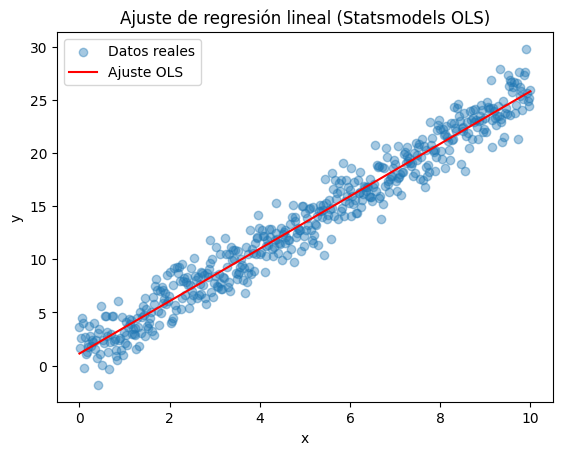

In [ ]:
# Visualizar los datos y el ajuste con matplotlib

import matplotlib.pyplot as plt

# Predicciones del modelo
y_pred = modelo.predict(X)
# Plot de datos reales
plt.scatter(x_data, y_data, alpha=0.4, label="Datos reales")
# Plot de la linea ajustada
plt.plot(x_data, y_pred, color="red", label="Ajuste OLS")

plt.title("Ajuste de regresión lineal (Statsmodels OLS)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

---> SciPy nos enseña cómo un modelo aprende parámetros minimizando una función de pérdida.  
---> Statsmodels aplica esa misma idea a la regresión lineal y además nos proporciona herramientas estadísticas para interpretar los resultados.

---
## Reporte Técnico: Comparativa Antes / Después

Completa la siguiente tabla con los valores reales que obtuviste durante el taller.

---

### Métricas de rendimiento

| Métrica | Pipeline original | Pipeline NumPy | Mejora |
|---------|:-----------------:|:--------------:|:------:|
| Tiempo total (s) | "0.481" | "0.132" | "3.7"x |
| RAM máxima (MiB) | "23" | "0" | -23 MiB |

---

### Conclusión estadística del modelo OLS

| Parámetro | Valor estimado | p-value | Significativo (p < 0.05) |
|-----------|:--------------:|:-------:|:------------------------:|
| Intercepto (b) | __ | __ | Sí / No |
| Pendiente (a) | __ | __ | Sí / No |
| R-squared | __ | — | — |

**Interpretación:**

El modelo explica aproximadamente ___ % de la varianza en los datos.
Los coeficientes son / no son estadísticamente significativos porque...


---
## Ejercicio Final — Aplicación Autónoma

Ahora es tu turno. Vas a repetir el proceso completo, pero con un dataset diferente
y con algunas variaciones.

### Dataset: Análisis de tiempos de entrega logística

Tienes datos de una empresa de logística con 800,000 registros.
Cada registro representa un envío con:
- `distancia_km`: distancia del recorrido.
- `peso_kg`: peso del paquete.
- `tiempo_entrega_h`: tiempo real de entrega en horas.

La relación esperada es: `tiempo_entrega = 0.05 * distancia + 1.2 * peso + ruido`

### Instrucciones

Completa cada celda de código usando lo que practicaste en el taller.
No copies el código anterior directamente — reescríbelo a tu manera.


In [ ]:
import numpy as np

# Creamos un dataset de logística
np.random.seed(7)
N = 800_000

distancia = np.random.uniform(5, 300, N)
peso = np.random.uniform(0.5, 20, N)
tiempo_entrega = 0.05 * distancia + 1.2 * peso + np.random.normal(0, 2, N)

datos_logistica = {
    "distancia_km":      list(distancia),
    "peso_kg":           list(peso),
    "tiempo_entrega_h":  list(tiempo_entrega),
}

print(f"Dataset generado: {N:,} registros")
print(f"Distancia promedio: {np.mean(distancia):.1f} km")
print(f"Peso promedio:      {np.mean(peso):.1f} kg")
print(f"Tiempo promedio:    {np.mean(tiempo_entrega):.1f} h")


### Tarea 1: Profiling del código ineficiente

Escribe primero una versión ineficiente con bucles `for` de la siguiente función:
`calcular_costo_envio(datos)` → costo = distancia * 0.8 + peso * 15

Luego aplica `cProfile` para medir cuánto tarda.


In [ ]:
import cProfile, pstats, io

# ── Tu código aquí ───────────────────────────────────────────────────────────
# 1. Escribe calcular_costo_envio() usando un bucle for (versión ineficiente)
# 2. Aplica cProfile para medir su tiempo de ejecución
# 3. Imprime el reporte con las top 10 funciones por cumtime





### Tarea 2: Decorador `@monitor_rendimiento` con umbral de alerta

Modifica el decorador `@monitor_rendimiento` que construiste en el taller para que,
además de imprimir las métricas, **lance un `Warning`** si el tiempo de ejecución
supera un umbral configurable (por defecto: 1 segundo).

Pista: el decorador puede aceptar argumentos usando un nivel extra de anidación.

```python
@monitor_rendimiento(umbral_segundos=1.0)
def mi_funcion(...):
    ...
```


In [ ]:
import warnings
import functools
import time
from memory_profiler import memory_usage

# ── Tu código aquí ───────────────────────────────────────────────────────────
# Implementa monitor_rendimiento con soporte para umbral_segundos.
# Recuerda: para decoradores con argumentos necesitas tres niveles de funciones.



### Tarea 3: Pipeline optimizado con NumPy

Reescribe el cálculo de costo de envío usando broadcasting y filtra los envíos
con costo mayor a 200 (envíos "costosos") usando fancy indexing.

Compara el tiempo con tu versión de bucles.


In [ ]:
# ── Tu código aquí ───────────────────────────────────────────────────────────
# 1. Convierte las listas del dataset a arrays NumPy
# 2. Calcula el costo con broadcasting (sin bucles)
# 3. Filtra envíos costosos con una máscara booleana
# 4. Mide el tiempo de ambas versiones y calcula el speedup





### Tarea 4: Regresión múltiple con Statsmodels

Ajusta un modelo OLS para predecir `tiempo_entrega_h` en función de
`distancia_km` y `peso_kg` (regresión múltiple).

Responde en una celda Markdown debajo:
- ¿Cuál variable tiene mayor impacto en el tiempo de entrega?
- ¿Es el modelo estadísticamente confiable? ¿Por qué?


In [ ]:
import statsmodels.api as sm
import pandas as pd


# ── Tu código aquí ───────────────────────────────────────────────────────────
# 1. Construye la matriz X con distancia y peso (más la constante)
# 2. Ajusta el modelo OLS
# 3. Imprime el summary
# 4. Extrae R-squared y p-values






#### Tu análisis:

*(Escribe aquí tu interpretación del modelo)*

- Variable con mayor impacto: ...
- R-squared: ...
- Confiabilidad del modelo: ...


---
## Resumen del taller

| Herramienta | Para qué sirve |
|-------------|----------------|
| `cProfile` | Medir tiempo de CPU por función |
| `memory_profiler` | Medir consumo de RAM en tiempo real |
| Decoradores | Agregar comportamiento a funciones sin modificarlas |
| NumPy broadcasting | Reemplazar bucles `for` con operaciones vectorizadas |
| Fancy indexing | Reemplazar `if/else` con máscaras booleanas |
| `scipy.optimize` | Minimizar funciones de pérdida |
| `statsmodels OLS` | Inferencia estadística: R², p-values, intervalos de confianza |

---

**Recursos de referencia:**
- NumPy linalg: https://numpy.org/doc/stable/reference/routines.linalg.html
- SciPy optimize: https://docs.scipy.org/doc/scipy/reference/optimize.html
- Statsmodels: https://www.statsmodels.org/stable/index.html
